# Bandit benchmark notebook

Этот ноутбук запускает benchmark-пайплайн (аналогично `src/run_benchmark.py`) на вашем датасете.

## 1) Настройки

In [9]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from run_benchmark import load_dataset
from bandit_benchmark import (
    CatBoostPolicy,
    LogisticTSLibPolicy,
    LaplaceThompsonViaBayesianLogRegPolicy,
    NeuralLaplaceThompsonViaBayesianLogRegPolicy,
    PartitionedTSLibPolicy,
    RandomPolicy,
    EpsilonGreedyPolicy,
    UCBPolicy,
    ThompsonSamplingPolicy,
    TreeThompsonSamplingPolicy,
    _NeuralActionRewardEncoder,
    build_expected_reward_estimator,
    default_scenario,
    default_five_scenarios,
    make_simulated_environment,
    preprocess_bandit_dataframe,
    run_scenarios,
    split_train_test_by_date,
)
from prepare_datasets import stage1_make_splits, stage2_scale_features


In [10]:
# Укажите путь к данным (.tsv или .parquet)
DATA_PATH = ROOT / 'data' / 'cdp_music_fs_small.tsv'
DATASET_NAME = DATA_PATH.stem
ARTIFACTS_DIR = ROOT / 'artifacts' / DATASET_NAME
DATASETS_DIR = ARTIFACTS_DIR / 'datasets'
PREPARED_TRAIN_PATH = DATASETS_DIR / 'train_variant_1_scaled.parquet'
PREPARED_TEST_PATH = DATASETS_DIR / 'test_variant_1_scaled.parquet'
USE_PREPARED_SPLITS = True
TRAIN_DAYS = 20
EPSILON = 0.1
SEED = 42
SIMULATE = False
STOCHASTIC_SIM = True
FULL_SCENARIOS = False
NEURAL_HIDDEN_DIMS = [128, 68]
USE_SAMPLED_DATASET = True
SAMPLE_FRACTION = 0.25  # доля строк для train/test при демо-прогоне
USE_CUSTOM_ENCODER = True
ENCODER_REP_DIM = 32
ENCODER_NN_LR = 1e-3
ENCODER_TRAIN_DATA_MODE = 'random_half'  # all | random_half | time_half


BOOTSTRAP_ENABLED = True
BOOTSTRAP_ITERATIONS = 20
BOOTSTRAP_CI = 0.95


## 2) Загрузка и препроцессинг

In [11]:
if USE_PREPARED_SPLITS and PREPARED_TRAIN_PATH.exists() and PREPARED_TEST_PATH.exists():
    train_df = pl.read_parquet(PREPARED_TRAIN_PATH)
    test_df = pl.read_parquet(PREPARED_TEST_PATH)
    print('loaded prepared splits')
else:
    # Stage 1: load -> split -> filter -> save
    train_s1, test_s1 = stage1_make_splits(str(DATA_PATH), str(DATASETS_DIR), TRAIN_DAYS, SEED)
    # Stage 2: scale features and save prepared datasets
    train_final, test_final = stage2_scale_features(train_s1, test_s1, str(DATASETS_DIR))
    train_df = pl.read_parquet(train_final)
    test_df = pl.read_parquet(test_final)

print('train:', train_df.height, 'test(random only):', test_df.height)


loaded prepared splits
train: 1772191 test(random only): 3241836


## 3) Конфиг политик и сценариев

In [12]:
policy_factories = {
    # 'random': lambda: RandomPolicy(seed=SEED),
    # 'epsilon_greedy': lambda: EpsilonGreedyPolicy(epsilon=EPSILON, seed=SEED),
    # 'ucb': lambda: UCBPolicy(),
    'thompson_sampling': lambda: ThompsonSamplingPolicy(seed=SEED),
}

try:
    import sklearn  # noqa: F401
    policy_factories['tree_thompson_sampling_refit'] = lambda: TreeThompsonSamplingPolicy(random_state=SEED, refit_when_update=False)
except Exception:
    print('sklearn is unavailable: skipping TreeThompsonSamplingPolicy')
try:
    import scipy  # noqa: F401
    policy_factories['laplace_ts_logreg'] = lambda: LaplaceThompsonViaBayesianLogRegPolicy(seed=SEED)
    try:
        import torch  # noqa: F401
        custom_encoder = None
        if USE_CUSTOM_ENCODER:
            feature_rows = train_df.select('features_list').to_series().to_list()
            non_empty_features = [row for row in feature_rows if isinstance(row, list) and len(row) > 0]
            if non_empty_features:
                feature_dim = len(non_empty_features[0])
                action_count = train_df.select('show').n_unique()
                custom_encoder = _NeuralActionRewardEncoder(
                    input_dim=feature_dim,
                    num_actions=action_count,
                    hidden_dims=NEURAL_HIDDEN_DIMS,
                    rep_dim=ENCODER_REP_DIM,
                    lr=ENCODER_NN_LR,
                    seed=SEED,
                )
            else:
                print('train_df has no non-empty features_list rows: encoder will be created by policy itself')
        policy_factories['neural_laplace_ts_logreg'] = lambda: NeuralLaplaceThompsonViaBayesianLogRegPolicy(
            seed=SEED,
            hidden_dims=NEURAL_HIDDEN_DIMS,
            encoder=custom_encoder,
            encoder_train_data_mode=ENCODER_TRAIN_DATA_MODE,
        )
    except Exception:
        print('torch is unavailable: skipping NeuralLaplaceThompsonViaBayesianLogRegPolicy')
except Exception:
    print('scipy is unavailable: skipping LaplaceThompsonViaBayesianLogRegPolicy')
try:
    import catboost  # noqa: F401
    policy_factories['catboost'] = lambda: CatBoostPolicy(random_seed=SEED)
except Exception:
    print('catboost is unavailable: skipping CatBoostPolicy')
# try:
#     import contextualbandits  # noqa: F401
#     policy_factories['logistic_ts'] = lambda: LogisticTSLibPolicy(random_seed=SEED)
#     policy_factories['partitioned_ts'] = lambda: PartitionedTSLibPolicy(random_seed=SEED)
# except Exception:
#     print('contextualbandits is unavailable: skipping LogisticTS/PartitionedTS')
scenarios = default_five_scenarios() if FULL_SCENARIOS else default_scenario()


## 4) Запуск benchmark

## 4.1) Опциональный сэмпл для быстрого прогона


In [13]:
if USE_SAMPLED_DATASET:
    if not (0.0 < SAMPLE_FRACTION <= 1.0):
        raise ValueError('SAMPLE_FRACTION must be in (0, 1]')
    train_eval_df = train_df.sample(fraction=SAMPLE_FRACTION, shuffle=True, seed=SEED).sort('date')
    test_eval_df = test_df.sample(fraction=SAMPLE_FRACTION, shuffle=True, seed=SEED).sort('date')
else:
    train_eval_df = train_df
    test_eval_df = test_df

print('eval train rows:', train_eval_df.height, 'of', train_df.height)
print('eval test rows:', test_eval_df.height, 'of', test_df.height)


eval train rows: 443047 of 1772191
eval test rows: 810459 of 3241836


In [14]:
env_reward = None
if SIMULATE:
    expected_fn = build_expected_reward_estimator(train_df)
    env_reward = make_simulated_environment(
        proba_predictor=expected_fn,
        stochastic=STOCHASTIC_SIM,
        seed=SEED,
    )

result = run_scenarios(
    train_df=train_eval_df,
    test_df=test_eval_df,
    policy_factories=policy_factories,
    scenarios=scenarios,
    env_reward=env_reward,
    show_progress=True,
)

metrics_df = result['metrics']
history_df = result['history']
action_stats_df = result['action_stats']
action_daily_stats_df = result['action_daily_stats']
action_sensitive_stats_df = result['action_sensitive_stats']

display(metrics_df.sort_values('ips_ctr', ascending=False).reset_index(drop=True))

ips_snips_cols = ['scenario', 'algo', 'impressions_total', 'impressions_extrapolated', 'ips_ctr', 'snips_ctr']
if set(ips_snips_cols).issubset(metrics_df.columns):
    print('IPS/SNIPS metrics:')
    display(metrics_df[ips_snips_cols].sort_values(['scenario', 'algo']).reset_index(drop=True))

sensitive_cols = ['scenario', 'algo', 'sensitive_impressions', 'ips_ctr_sensitive', 'ips_regret_sens']
if set(sensitive_cols).issubset(metrics_df.columns):
    print('sensitive IPS metrics (rows with len(candidates) > 1):')
    display(metrics_df[sensitive_cols].sort_values(['ips_ctr_sensitive', 'scenario', 'algo'], ascending=[False, True, True]).reset_index(drop=True))

print('history rows:', len(history_df))
if SIMULATE:
    display(action_stats_df)
    display(action_daily_stats_df)
    display(action_sensitive_stats_df)


case_2_random_pretrain_online_update_

case_2_random_pretrain_online_update_daily/thompson_sampling: train_unique_actions=51


case_2_random_pretrain_online_update_

case_2_random_pretrain_online_update_daily/tree_thompson_sampling_refit: train_unique_actions=51


case_2_random_pretrain_online_update_

...

IPS/SNIPS metrics:


,scenario,algo,impressions_total,impressions_extrapolated,ips_ctr,snips_ctr
0,case_2_random_pretrain_online_update_daily,catboost,810459,810732.0,0.021290,0.021283
1,case_2_random_pretrain_online_update_daily,laplace_ts_logreg,810459,810755.0,0.022913,0.022905
2,case_2_random_pretrain_online_update_daily,neural_laplace_ts_logreg,810459,809211.0,0.022808,0.022843
3,case_2_random_pretrain_online_update_daily,thompson_sampling,810459,808409.0,0.023589,0.023649
4,case_2_random_pretrain_online_update_daily,tree_thompson_sampling_refit,810459,809626.0,0.023643,0.023668


sensitive IPS metrics (rows with len(candidates) > 1):


,scenario,algo,sensitive_impressions,ips_ctr_sensitive,ips_regret_sens
0,case_2_random_pretrain_online_update_daily,tree_thompson_sampling_refit,375394,0.029263,0.018910
1,case_2_random_pretrain_online_update_daily,thompson_sampling,375394,0.029145,0.018977
2,case_2_random_pretrain_online_update_daily,laplace_ts_logreg,375394,0.027686,0.019493
3,case_2_random_pretrain_online_update_daily,neural_laplace_ts_logreg,375394,0.027459,0.019640
4,case_2_random_pretrain_online_update_daily,catboost,375394,0.024183,0.020823


history rows: 2972113


## 4.2) Bootstrap для IPS/SNIPS
Запускает `run_scenarios` на bootstrap-выборках test и считает средние метрики с доверительными интервалами.

In [15]:
bootstrap_summary_df = pd.DataFrame()
bootstrap_runs_df = pd.DataFrame()

if BOOTSTRAP_ENABLED:
    alpha = 1.0 - BOOTSTRAP_CI
    bootstrap_metrics_parts = []

    for i in range(BOOTSTRAP_ITERATIONS):
        boot_test_df = test_eval_df.sample(
            fraction=1.0,
            with_replacement=True,
            shuffle=True,
            seed=SEED + i,
        )
        boot_result = run_scenarios(
            train_df=train_eval_df,
            test_df=boot_test_df,
            policy_factories=policy_factories,
            scenarios=scenarios,
            env_reward=env_reward,
            show_progress=False,
        )
        boot_metrics = boot_result['metrics'][['scenario', 'algo', 'impressions_total', 'impressions_extrapolated', 'ips_ctr', 'snips_ctr']].copy()
        boot_metrics['extrapolated_ratio'] = boot_metrics['impressions_extrapolated'] / boot_metrics['impressions_total']
        boot_metrics['bootstrap_iter'] = i
        bootstrap_metrics_parts.append(boot_metrics)

    bootstrap_runs_df = pd.concat(bootstrap_metrics_parts, ignore_index=True)

    bootstrap_summary_df = (
        bootstrap_runs_df
        .groupby(['scenario', 'algo'], as_index=False)
        .agg(
            ips_ctr_mean=('ips_ctr', 'mean'),
            ips_ctr_ci_low=('ips_ctr', lambda s: s.quantile(alpha / 2)),
            ips_ctr_ci_high=('ips_ctr', lambda s: s.quantile(1 - alpha / 2)),
            snips_ctr_mean=('snips_ctr', 'mean'),
            snips_ctr_ci_low=('snips_ctr', lambda s: s.quantile(alpha / 2)),
            snips_ctr_ci_high=('snips_ctr', lambda s: s.quantile(1 - alpha / 2)),
            extrapolated_ratio_mean=('extrapolated_ratio', 'mean'),
            extrapolated_ratio_ci_low=('extrapolated_ratio', lambda s: s.quantile(alpha / 2)),
            extrapolated_ratio_ci_high=('extrapolated_ratio', lambda s: s.quantile(1 - alpha / 2)),
        )
        .sort_values(['scenario', 'algo'])
        .reset_index(drop=True)
    )

    print(f'Bootstrap iterations: {BOOTSTRAP_ITERATIONS}, CI: {BOOTSTRAP_CI:.0%}')
    display(bootstrap_summary_df)
else:
    print('Bootstrap is disabled. Set BOOTSTRAP_ENABLED=True to run.')


Bootstrap iterations: 20, CI: 95%


,scenario,algo,ips_ctr_mean,ips_ctr_ci_low,ips_ctr_ci_high,snips_ctr_mean,snips_ctr_ci_low,snips_ctr_ci_high,extrapolated_ratio_mean,extrapolated_ratio_ci_low,extrapolated_ratio_ci_high
0,case_2_random_pretrain_online_update_daily,catboost,0.021334,0.020913,0.021744,0.021327,0.020899,0.021705,1.000315,0.998910,1.001999
1,case_2_random_pretrain_online_update_daily,laplace_ts_logreg,0.023502,0.023074,0.023869,0.023518,0.023105,0.023866,0.999307,0.997689,1.001059
2,case_2_random_pretrain_online_update_daily,neural_laplace_ts_logreg,0.023409,0.023069,0.023827,0.023419,0.023064,0.023841,0.999559,0.997914,1.000999
3,case_2_random_pretrain_online_update_daily,thompson_sampling,0.024015,0.023626,0.024406,0.024029,0.023607,0.024397,0.999412,0.996602,1.002367
4,case_2_random_pretrain_online_update_daily,tree_thompson_sampling_refit,0.024085,0.023725,0.024486,0.024113,0.023743,0.024491,0.998856,0.996207,1.003166


In [16]:
kek = history_df[history_df["algo"] == "catboost"]

In [17]:
history_df[history_df["algo"] == "catboost"]["ips_reward"].value_counts()

ips_reward
0.0    582736
1.0      8177
2.0      2551
3.0       853
4.0       256
5.0        60
6.0        13
7.0         1
8.0         1
Name: count, dtype: int64

In [18]:
history_df[history_df["algo"] == "laplace_ts_logreg"]["ips_reward"].value_counts()

ips_reward
0.0    582485
1.0      8177
2.0      2841
3.0       995
4.0       283
5.0       101
6.0        11
8.0         2
7.0         1
Name: count, dtype: int64

In [19]:
history_df[history_df["algo"] == "thompson_sampling"]["ips_reward"].value_counts()

ips_reward
0.0    581290
1.0      8177
2.0      2925
3.0      1072
4.0       308
5.0       102
6.0        17
8.0         3
7.0         1
Name: count, dtype: int64

## 5) Графики по сценариям

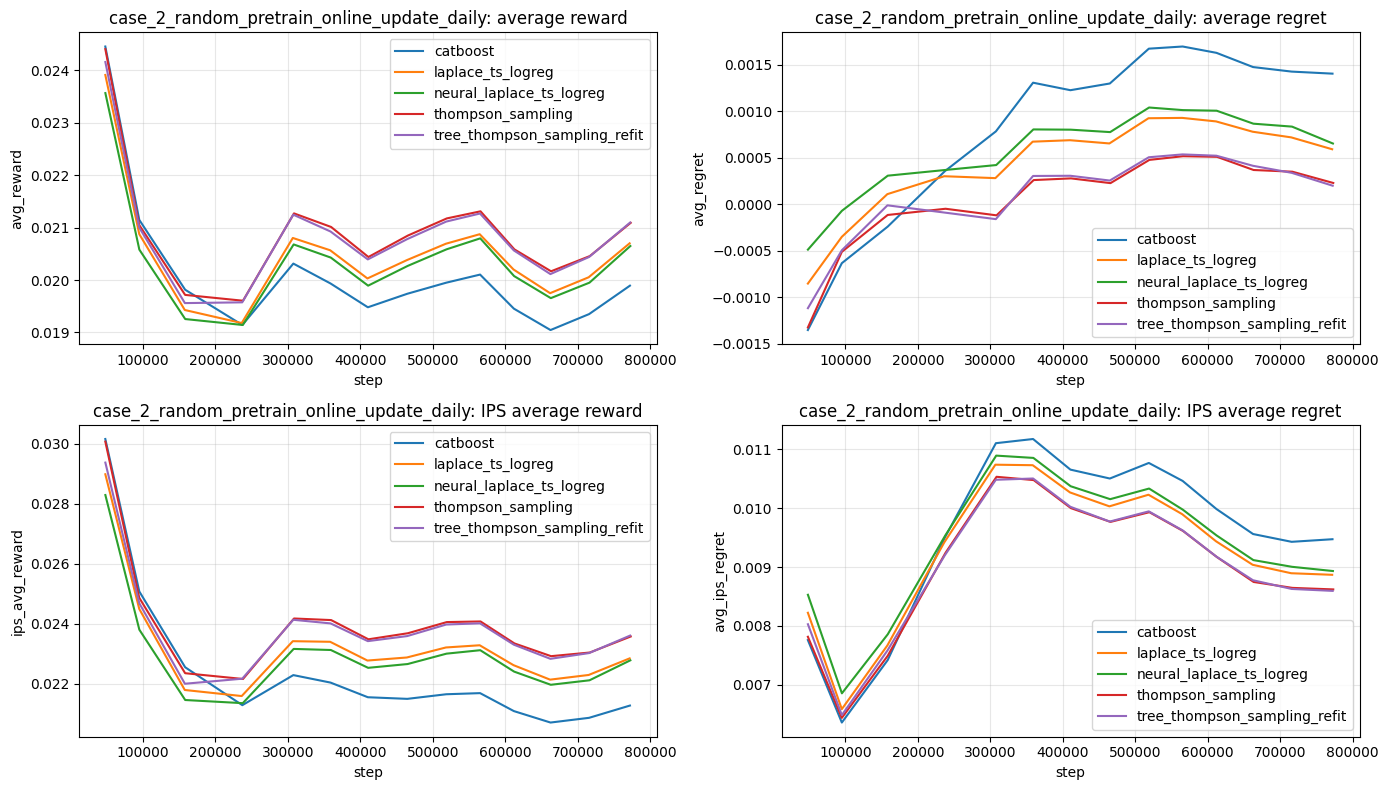

In [20]:
if not history_df.empty:
    for scenario_name, part in history_df.groupby('scenario'):
        fig, axes = plt.subplots(2, 2, figsize=(14, 8))

        for algo, algo_df in part.groupby('algo'):
            max_step = int(algo_df['step'].max()) if len(algo_df) else 0
            stride = max(1, int(round(max_step * 0.05)))  # каждые 5%
            ds = algo_df.iloc[stride::stride] if len(algo_df) > stride else algo_df  # стартуем с 5%

            axes[0, 0].plot(ds['step'], ds['avg_reward'], label=algo)
            axes[0, 1].plot(ds['step'], ds['avg_regret'], label=algo)
            axes[1, 0].plot(ds['step'], ds['ips_avg_reward'], label=algo)
            axes[1, 1].plot(ds['step'], ds['avg_ips_regret'], label=algo)

        axes[0, 0].set_title(f'{scenario_name}: average reward')
        axes[0, 0].set_xlabel('step')
        axes[0, 0].set_ylabel('avg_reward')

        axes[0, 1].set_title(f'{scenario_name}: average regret')
        axes[0, 1].set_xlabel('step')
        axes[0, 1].set_ylabel('avg_regret')

        axes[1, 0].set_title(f'{scenario_name}: IPS average reward')
        axes[1, 0].set_xlabel('step')
        axes[1, 0].set_ylabel('ips_avg_reward')

        axes[1, 1].set_title(f'{scenario_name}: IPS average regret')
        axes[1, 1].set_xlabel('step')
        axes[1, 1].set_ylabel('avg_ips_regret')

        for ax in axes.ravel():
            ax.grid(True, alpha=0.3)
            ax.legend()

        fig.tight_layout()
        plt.show()
else:
    print('History is empty.')


## 6) График sensitive IPS metrics
Показывает `ips_ctr_sensitive` и `ips_regret_sens` по алгоритмам внутри каждого сценария.

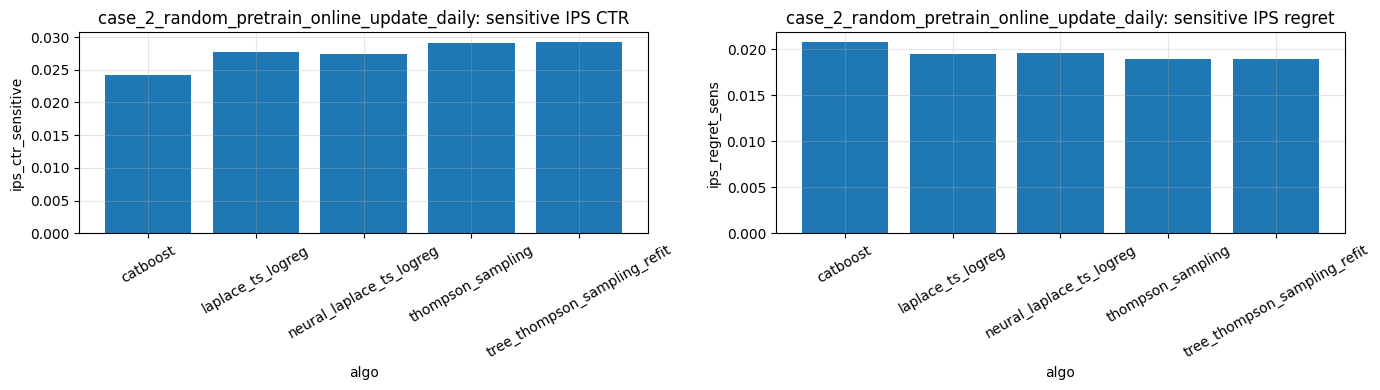

In [21]:
if set(sensitive_cols).issubset(metrics_df.columns):
    sensitive_plot_df = metrics_df[sensitive_cols].copy()
    sensitive_plot_df = sensitive_plot_df[sensitive_plot_df['sensitive_impressions'] > 0]

    if sensitive_plot_df.empty:
        print('Нет данных для sensitive IPS графика (sensitive_impressions == 0).')
    else:
        for scenario_name, part in sensitive_plot_df.groupby('scenario'):
            fig, axes = plt.subplots(1, 2, figsize=(14, 4))
            part = part.sort_values('algo')

            axes[0].bar(part['algo'], part['ips_ctr_sensitive'])
            axes[0].set_title(f'{scenario_name}: sensitive IPS CTR')
            axes[0].set_xlabel('algo')
            axes[0].set_ylabel('ips_ctr_sensitive')
            axes[0].tick_params(axis='x', rotation=30)

            axes[1].bar(part['algo'], part['ips_regret_sens'])
            axes[1].set_title(f'{scenario_name}: sensitive IPS regret')
            axes[1].set_xlabel('algo')
            axes[1].set_ylabel('ips_regret_sens')
            axes[1].tick_params(axis='x', rotation=30)

            for ax in axes:
                ax.grid(True, alpha=0.3)

            fig.tight_layout()
            plt.show()
else:
    print('Sensitive IPS колонки отсутствуют в metrics_df.')


## 6.1) Sensitive IPS метрики по шагам
Показывает динамику sensitive-метрик, которые теперь логируются в `history_df`.


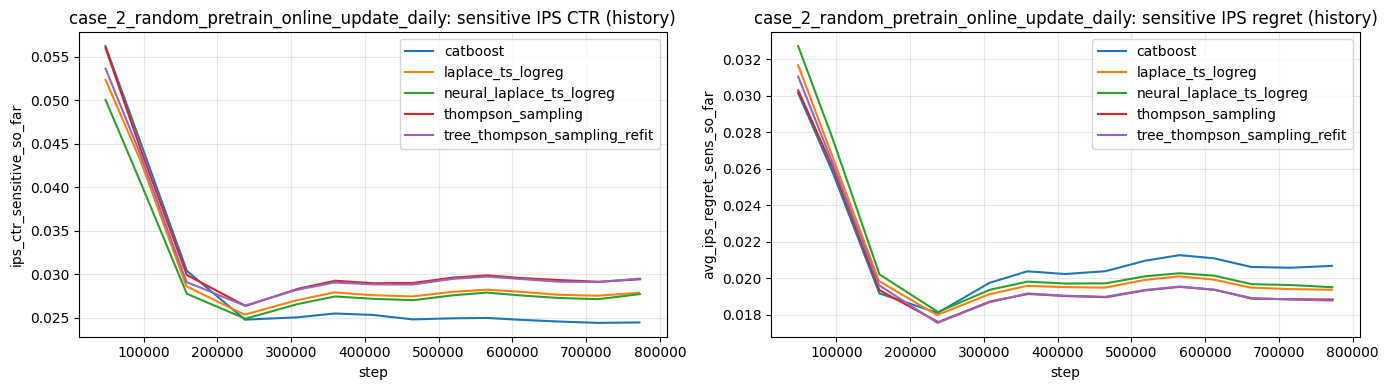

In [22]:
if not history_df.empty and {'ips_ctr_sensitive_so_far', 'avg_ips_regret_sens_so_far'}.issubset(history_df.columns):
    for scenario_name, part in history_df.groupby('scenario'):
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        for algo, algo_df in part.groupby('algo'):
            max_step = int(algo_df['step'].max()) if len(algo_df) else 0
            stride = max(1, int(round(max_step * 0.05)))
            ds = algo_df.iloc[stride::stride] if len(algo_df) > stride else algo_df

            axes[0].plot(ds['step'], ds['ips_ctr_sensitive_so_far'], label=algo)
            axes[1].plot(ds['step'], ds['avg_ips_regret_sens_so_far'], label=algo)

        axes[0].set_title(f'{scenario_name}: sensitive IPS CTR (history)')
        axes[0].set_xlabel('step')
        axes[0].set_ylabel('ips_ctr_sensitive_so_far')

        axes[1].set_title(f'{scenario_name}: sensitive IPS regret (history)')
        axes[1].set_xlabel('step')
        axes[1].set_ylabel('avg_ips_regret_sens_so_far')

        for ax in axes:
            ax.grid(True, alpha=0.3)
            ax.legend()

        fig.tight_layout()
        plt.show()
else:
    print('Нет sensitive history-метрик в history_df.')



## 7) Графики по статистикам action'ов
Показывает динамику общего числа уникальных action'ов и количества новых action'ов по дням/checkpoint'ам.

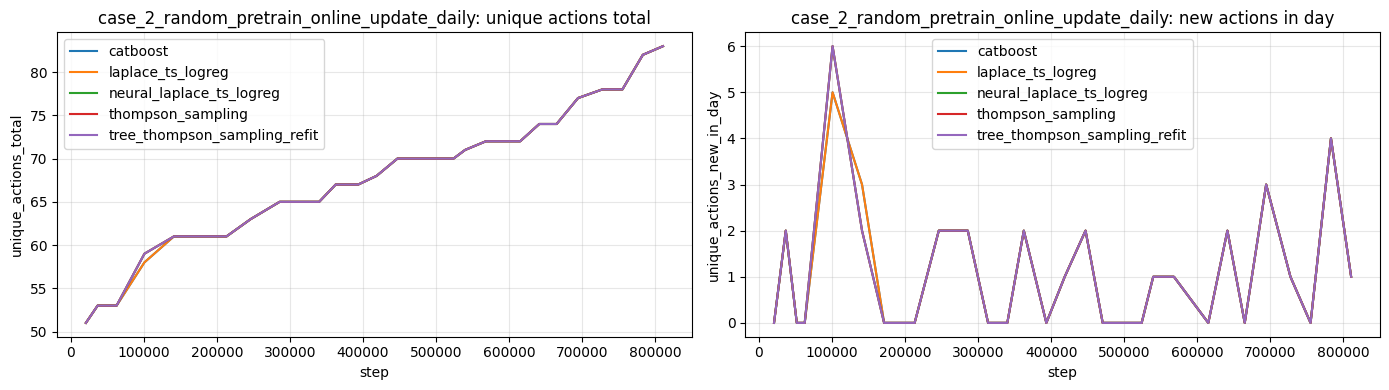

In [ ]:
if not action_stats_df.empty:
    for scenario_name, part in action_stats_df.groupby('scenario'):
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        for algo, algo_df in part.groupby('algo'):
            algo_df = algo_df.sort_values('step')
            axes[0].plot(algo_df['step'], algo_df['unique_actions_total'], label=algo)
            axes[1].plot(algo_df['step'], algo_df['unique_actions_new_in_day'], label=algo)

        axes[0].set_title(f"{scenario_name}: unique actions total")
        axes[0].set_xlabel('step')
        axes[0].set_ylabel('unique_actions_total')

        axes[1].set_title(f"{scenario_name}: new actions in day")
        axes[1].set_xlabel('step')
        axes[1].set_ylabel('unique_actions_new_in_day')

        for ax in axes:
            ax.grid(True, alpha=0.3)
            ax.legend()

        fig.tight_layout()
        plt.show()
else:
    print('action_stats_df is empty.')


## 8) Распределение показов по action и дням


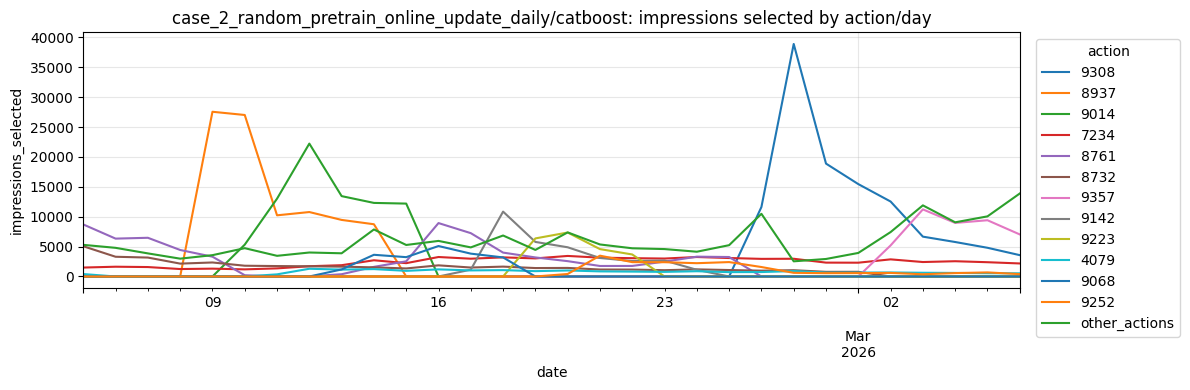

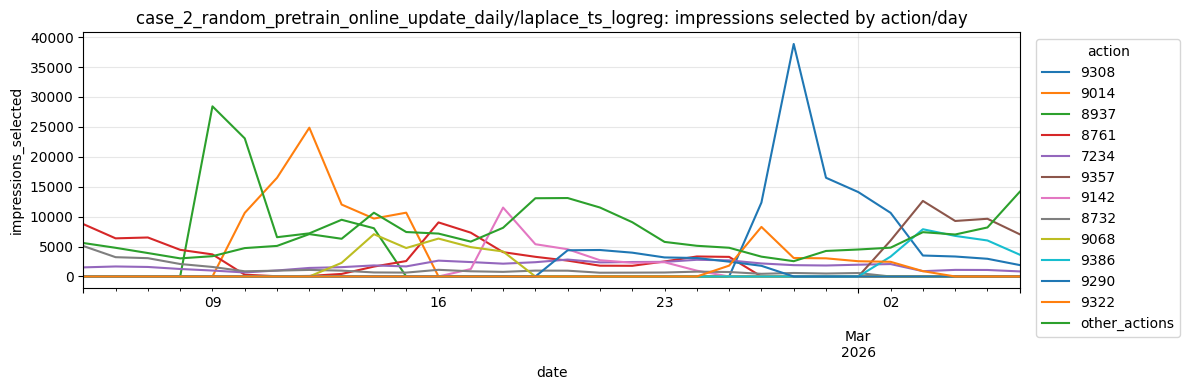

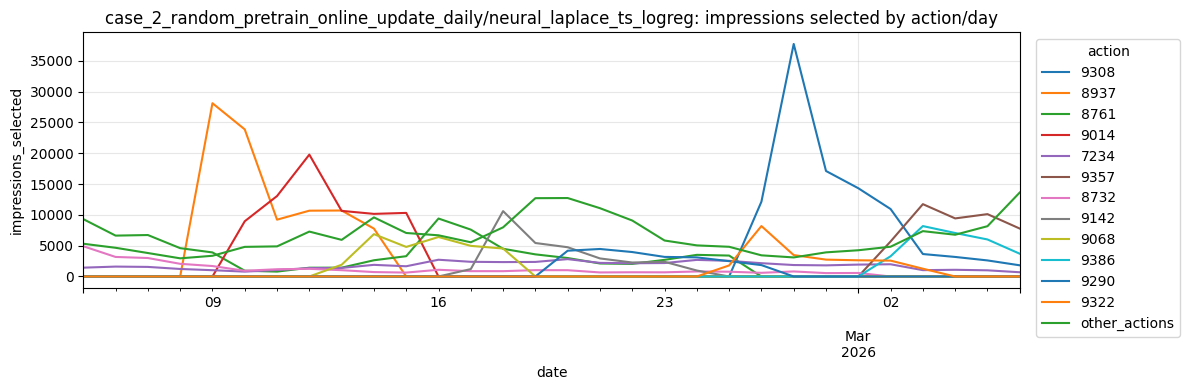

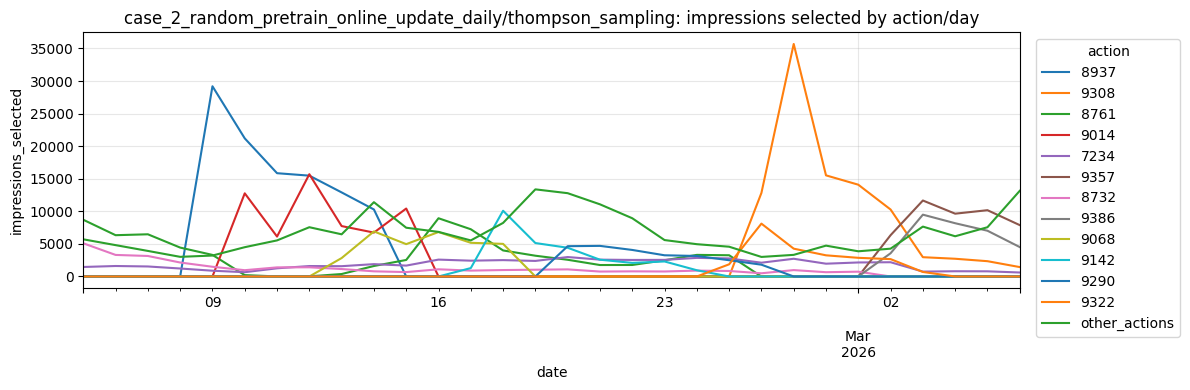

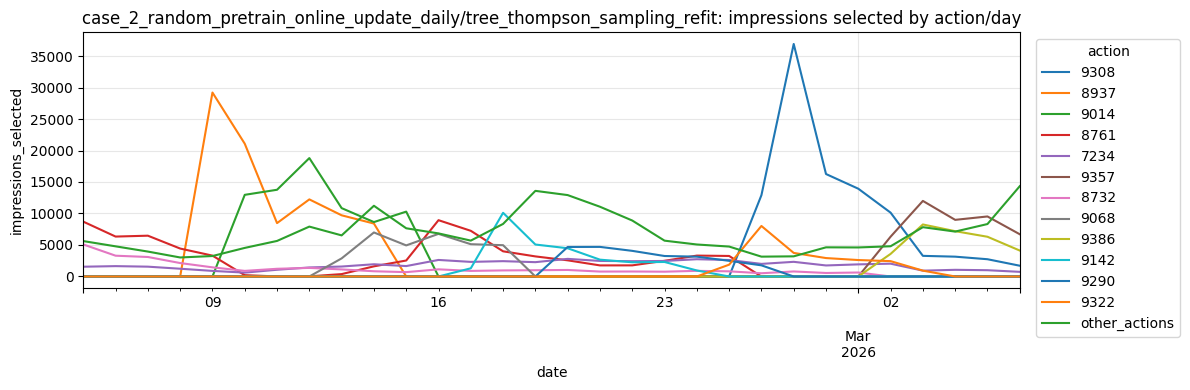

In [ ]:
if not action_daily_stats_df.empty:
    top_actions_n = 12

    for scenario_name, part in action_daily_stats_df.groupby('scenario'):
        for algo_name, algo_df in part.groupby('algo'):
            pivot_cnt = algo_df.pivot_table(index='date', columns='action', values='impressions_selected', aggfunc='sum').fillna(0)

            if pivot_cnt.shape[1] > top_actions_n:
                action_totals = pivot_cnt.sum(axis=0).sort_values(ascending=False)
                top_actions = action_totals.head(top_actions_n).index
                other_actions = [a for a in pivot_cnt.columns if a not in top_actions]

                plot_df = pivot_cnt.loc[:, top_actions].copy()
                if other_actions:
                    plot_df['other_actions'] = pivot_cnt.loc[:, other_actions].sum(axis=1)
            else:
                plot_df = pivot_cnt.copy()

            fig, ax = plt.subplots(figsize=(12, 4))
            plot_df.sort_index().plot(ax=ax)
            ax.set_title(f'{scenario_name}/{algo_name}: impressions selected by action/day')
            ax.set_xlabel('date')
            ax.set_ylabel('impressions_selected')
            ax.grid(True, alpha=0.3)
            ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), title='action')
            fig.tight_layout()
            plt.show()
else:
    print('action_daily_stats_df is empty.')


## 9) Сохранение артефактов

In [ ]:
OUT_DIR = ARTIFACTS_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)

metrics_path = OUT_DIR / 'metrics.csv'
history_path = OUT_DIR / 'history.csv'
action_stats_path = OUT_DIR / 'action_stats.csv'
action_daily_stats_path = OUT_DIR / 'action_daily_stats.csv'
action_sensitive_stats_path = OUT_DIR / 'action_sensitive_stats.csv'

metrics_df.to_csv(metrics_path, index=False)
history_df.to_csv(history_path, index=False)
action_stats_df.to_csv(action_stats_path, index=False)
action_daily_stats_df.to_csv(action_daily_stats_path, index=False)
action_sensitive_stats_df.to_csv(action_sensitive_stats_path, index=False)

print('saved metrics:', metrics_path)
print('saved history:', history_path)
print('saved action stats:', action_stats_path)
print('saved action daily stats:', action_daily_stats_path)
print('saved action sensitive stats:', action_sensitive_stats_path)


bootstrap_summary_path = OUT_DIR / 'bootstrap_summary.csv'
bootstrap_runs_path = OUT_DIR / 'bootstrap_runs.csv'

if not bootstrap_summary_df.empty:
    bootstrap_summary_df.to_csv(bootstrap_summary_path, index=False)
    print('saved bootstrap summary:', bootstrap_summary_path)
if not bootstrap_runs_df.empty:
    bootstrap_runs_df.to_csv(bootstrap_runs_path, index=False)
    print('saved bootstrap runs:', bootstrap_runs_path)


saved metrics: /Users/ogrobertino/BanditsResearch/artifacts/cdp_music_fs_small/metrics.csv
saved history: /Users/ogrobertino/BanditsResearch/artifacts/cdp_music_fs_small/history.csv
saved action stats: /Users/ogrobertino/BanditsResearch/artifacts/cdp_music_fs_small/action_stats.csv
saved action daily stats: /Users/ogrobertino/BanditsResearch/artifacts/cdp_music_fs_small/action_daily_stats.csv
saved action sensitive stats: /Users/ogrobertino/BanditsResearch/artifacts/cdp_music_fs_small/action_sensitive_stats.csv
saved bootstrap summary: /Users/ogrobertino/BanditsResearch/artifacts/cdp_music_fs_small/bootstrap_summary.csv
saved bootstrap runs: /Users/ogrobertino/BanditsResearch/artifacts/cdp_music_fs_small/bootstrap_runs.csv
